In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#1.Load Data

In [2]:
df = pd.read_csv('./data/Salaries.csv')
df

,Position,Level,Salary
0,Business Analyst,1,45000
1,Junior Consultant,2,50000
2,Senior Consultant,3,60000
3,Manager,4,80000
4,Country Manager,5,110000
5,Region Manager,6,150000
6,Partner,7,200000
7,Senior Partner,8,300000
8,C-level,9,500000
9,CEO,10,1000000


In [3]:
X = df.Level
X

0     1
1     2
2     3
3     4
4     5
5     6
6     7
7     8
8     9
9    10
Name: Level, dtype: int64

In [4]:
y = df.Salary
y

0      45000
1      50000
2      60000
3      80000
4     110000
5     150000
6     200000
7     300000
8     500000
9    1000000
Name: Salary, dtype: int64

Text(0, 0.5, 'Salary')

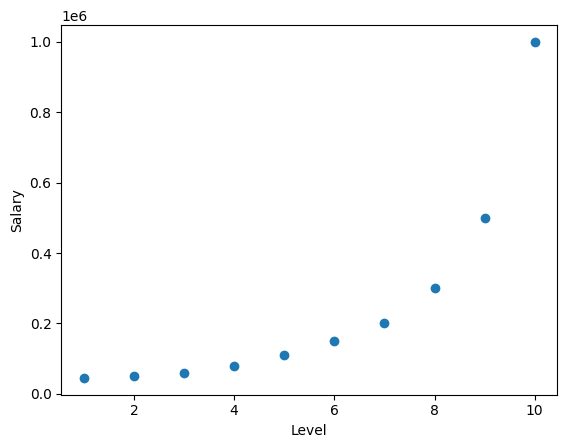

In [5]:
plt.scatter(X, y)
plt.xlabel("Level")
plt.ylabel("Salary")

#2.Linear Regression

In [6]:
def r2score(y_pred, y):
    rss = np.sum((y_pred - y) ** 2)
    tss = np.sum((y-y.mean()) ** 2)

    r2 = 1 - (rss / tss)
    return r2

In [7]:
class LinearRegression:
    def __init__(self, X_data, y_target, learning_rate=0.01, num_epochs=10000):
        self.X_data = X_data
        self.y_target = y_target
        self.learning_rate = learning_rate
        self.num_epochs = num_epochs
        self.num_samples = self.X_data.shape[0]

        # Initial Coefficients
        self.theta = np.random.randn(self.X_data.shape[1])
        self.losses = []

    def compute_loss(self, y_pred, y_target):
        loss = (y_pred-y_target)*(y_pred-y_target)
        loss = np.mean(loss)
        return loss

    def predict(self, X_data):
        y_pred = X_data.dot(self.theta)
        return y_pred

    def fit(self):
        for epoch in range(self.num_epochs):
            # predict
            y_pred = self.predict(self.X_data)

            # compute loss
            loss = self.compute_loss(y_pred, self.y_target)
            self.losses.append(loss)

            # compute gradient
            k = 2*(y_pred-self.y_target)
            gradients = self.X_data.T.dot(k)/self.num_samples

            # update weight
            self.theta = self.theta - self.learning_rate*gradients

            print(f'Epoch: {epoch} - Loss: {loss}')

        return {
            'loss': sum(self.losses)/len(self.losses),
            'weight': self.theta
        }

In [8]:
X_linear = X.values.reshape(-1, 1)
X_linear = np.hstack((np.ones((X_linear.shape[0], 1)), X_linear))

In [9]:
X_linear

array([[ 1.,  1.],
       [ 1.,  2.],
       [ 1.,  3.],
       [ 1.,  4.],
       [ 1.,  5.],
       [ 1.,  6.],
       [ 1.,  7.],
       [ 1.,  8.],
       [ 1.,  9.],
       [ 1., 10.]])

In [10]:
linear_model = LinearRegression(X_linear, y)
linear_model.fit()

Epoch: 0 - Loss: 142915553738.3827
Epoch: 1 - Loss: 40361268061.57771
Epoch: 2 - Loss: 35586086392.2826
Epoch: 3 - Loss: 35297736464.85508
Epoch: 4 - Loss: 35215829330.28697
Epoch: 5 - Loss: 35143969703.10222
Epoch: 6 - Loss: 35073141859.789734
Epoch: 7 - Loss: 35002927361.90647
Epoch: 8 - Loss: 34933302266.94871
Epoch: 9 - Loss: 34864260772.21663
Epoch: 10 - Loss: 34795797946.71864
Epoch: 11 - Loss: 34727908938.55574
Epoch: 12 - Loss: 34660588938.2275
Epoch: 13 - Loss: 34593833176.623535
Epoch: 14 - Loss: 34527636924.60917
Epoch: 15 - Loss: 34461995492.68682
Epoch: 16 - Loss: 34396904230.66369
Epoch: 17 - Loss: 34332358527.322315
Epoch: 18 - Loss: 34268353810.09386
Epoch: 19 - Loss: 34204885544.734234
Epoch: 20 - Loss: 34141949235.00285
Epoch: 21 - Loss: 34079540422.344093
Epoch: 22 - Loss: 34017654685.571484
Epoch: 23 - Loss: 33956287640.554466
Epoch: 24 - Loss: 33895434939.907837
Epoch: 25 - Loss: 33835092272.683723
Epoch: 26 - Loss: 33775255364.066204
Epoch: 27 - Loss: 33715919975.

{'loss': np.float64(26812263425.692398),
 'weight': array([-195333.33333333,   80878.78787879])}

In [11]:
y_pred = linear_model.predict(X_linear)

In [12]:
r2score(y_pred, y)

np.float64(0.6690412331929895)

In [13]:
linear_model.theta

array([-195333.33333333,   80878.78787879])

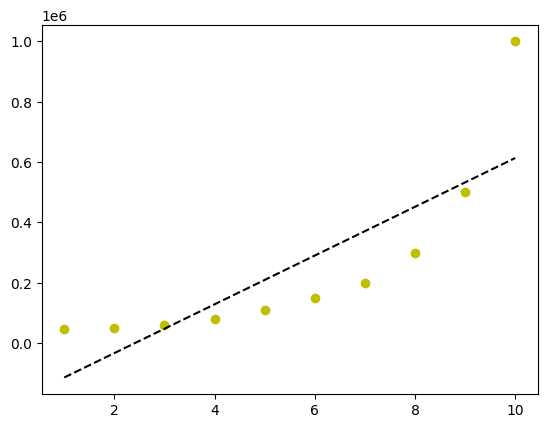

In [14]:
plt.plot(X, y, 'yo', X, linear_model.theta[1]*X + linear_model.theta[0], '--k')
plt.show()

#3.Polymial Regression

In [15]:
def create_polynomial_features(X, degree=2):
    """Creates the polynomial features
    Args:
        X: A array tensor for the data.
        degree: A intege for the degree of
        the generated polynomial function.
    """
    X_new = X
    for d in range(2, degree+1):
        X_new = np.c_[X_new, np.power(X, d)]
    return X_new

##3.1.Polymial Regression with degree = 2

In [16]:
X_poly = create_polynomial_features(X, degree=2)
X_poly

array([[  1,   1],
       [  2,   4],
       [  3,   9],
       [  4,  16],
       [  5,  25],
       [  6,  36],
       [  7,  49],
       [  8,  64],
       [  9,  81],
       [ 10, 100]])

In [17]:
X_poly = np.hstack((np.ones((X_poly.shape[0], 1)), X_poly))
X_poly

array([[  1.,   1.,   1.],
       [  1.,   2.,   4.],
       [  1.,   3.,   9.],
       [  1.,   4.,  16.],
       [  1.,   5.,  25.],
       [  1.,   6.,  36.],
       [  1.,   7.,  49.],
       [  1.,   8.,  64.],
       [  1.,   9.,  81.],
       [  1.,  10., 100.]])

In [18]:
poly_model = LinearRegression(X_poly, y, learning_rate=0.0001, num_epochs=10000)
poly_model.fit()

Epoch: 0 - Loss: 142900677412.6739
Epoch: 1 - Loss: 45666350902.89484
Epoch: 2 - Loss: 22697087005.12616
Epoch: 3 - Loss: 17268313152.99422
Epoch: 4 - Loss: 15982389280.583408
Epoch: 5 - Loss: 15674959071.088665
Epoch: 6 - Loss: 15598640829.410608
Epoch: 7 - Loss: 15576912270.315424
Epoch: 8 - Loss: 15568081016.551764
Epoch: 9 - Loss: 15562299841.83601
Epoch: 10 - Loss: 15557242949.334448
Epoch: 11 - Loss: 15552361010.509466
Epoch: 12 - Loss: 15547524276.592709
Epoch: 13 - Loss: 15542702098.354656
Epoch: 14 - Loss: 15537887232.651495
Epoch: 15 - Loss: 15533077964.57085
Epoch: 16 - Loss: 15528273884.90452
Epoch: 17 - Loss: 15523474892.839905
Epoch: 18 - Loss: 15518680960.408115
Epoch: 19 - Loss: 15513892076.849506
Epoch: 20 - Loss: 15509108235.47351
Epoch: 21 - Loss: 15504329430.55513
Epoch: 22 - Loss: 15499555656.601843
Epoch: 23 - Loss: 15494786908.180536
Epoch: 24 - Loss: 15490023179.87655
Epoch: 25 - Loss: 15485264466.284058
Epoch: 26 - Loss: 15480510762.00375
Epoch: 27 - Loss: 1547

{'loss': np.float64(11093781382.383722),
 'weight': array([ 14599.79807847, -47837.70479542,  12584.30748081])}

In [19]:
y_pred = poly_model.predict(X_poly)
r2score(y_pred, y)

np.float64(0.8736076108975659)

In [20]:
poly_model.theta

array([ 14599.79807847, -47837.70479542,  12584.30748081])

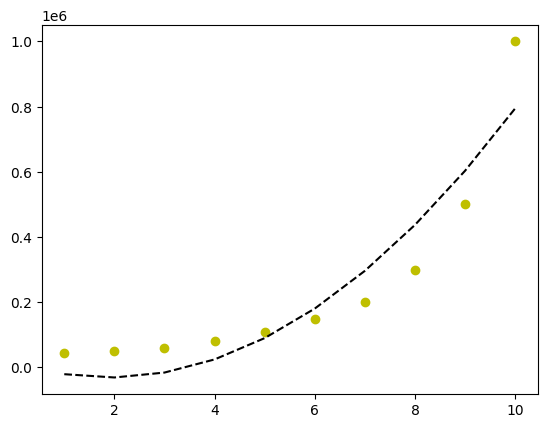

In [21]:
X_plot = df.Level
y_func = poly_model.theta[2]*X*X + poly_model.theta[1]*X + poly_model.theta[0]
plt.plot(X_plot, y, 'yo', X, y_func, '--k')
plt.show()

##3.2.Polymial Regression with degree = 3

In [22]:
X_poly = create_polynomial_features(X, degree=3)
X_poly

array([[   1,    1,    1],
       [   2,    4,    8],
       [   3,    9,   27],
       [   4,   16,   64],
       [   5,   25,  125],
       [   6,   36,  216],
       [   7,   49,  343],
       [   8,   64,  512],
       [   9,   81,  729],
       [  10,  100, 1000]])

In [23]:
X_poly = np.hstack((np.ones((X_poly.shape[0], 1)), X_poly))
X_poly

array([[   1.,    1.,    1.,    1.],
       [   1.,    2.,    4.,    8.],
       [   1.,    3.,    9.,   27.],
       [   1.,    4.,   16.,   64.],
       [   1.,    5.,   25.,  125.],
       [   1.,    6.,   36.,  216.],
       [   1.,    7.,   49.,  343.],
       [   1.,    8.,   64.,  512.],
       [   1.,    9.,   81.,  729.],
       [   1.,   10.,  100., 1000.]])

In [24]:
poly_model = LinearRegression(X_poly, y, learning_rate=0.0000001, num_epochs=10000)
poly_model.fit()

Epoch: 0 - Loss: 143165521256.97845
Epoch: 1 - Loss: 132474081885.35428
Epoch: 2 - Loss: 122622239770.6519
Epoch: 3 - Loss: 113544061164.24663
Epoch: 4 - Loss: 105178790108.62619
Epoch: 5 - Loss: 97470441824.36823
Epoch: 6 - Loss: 90367428028.52394
Epoch: 7 - Loss: 83822211676.82771
Epoch: 8 - Loss: 77790988819.07329
Epoch: 9 - Loss: 72233395438.4542
Epoch: 10 - Loss: 67112237312.872025
Epoch: 11 - Loss: 62393241090.29309
Epoch: 12 - Loss: 58044824912.20943
Epoch: 13 - Loss: 54037887050.08751
Epoch: 14 - Loss: 50345611140.24113
Epoch: 15 - Loss: 46943286713.65029
Epoch: 16 - Loss: 43808143819.61149
Epoch: 17 - Loss: 40919200636.42696
Epoch: 18 - Loss: 38257123049.25893
Epoch: 19 - Loss: 35804095255.364006
Epoch: 20 - Loss: 33543700530.726063
Epoch: 21 - Loss: 31460811360.110107
Epoch: 22 - Loss: 29541488195.226288
Epoch: 23 - Loss: 27772886163.4365
Epoch: 24 - Loss: 26143169102.645702
Epoch: 25 - Loss: 24641430347.05142
Epoch: 26 - Loss: 23257619733.604805
Epoch: 27 - Loss: 21982476340

{'loss': np.float64(6979628861.528573),
 'weight': array([   1.072339  ,  -98.98833157, -535.84582452,  889.87618071])}

In [25]:
y_pred = poly_model.predict(X_poly)
r2score(y_pred, y)

np.float64(0.9180472733328722)

In [26]:
poly_model.theta

array([   1.072339  ,  -98.98833157, -535.84582452,  889.87618071])

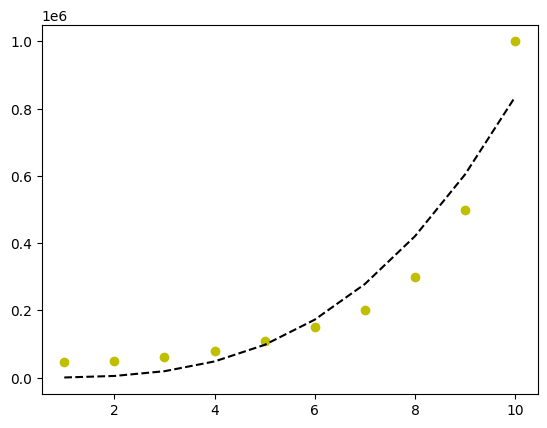

In [27]:
X_plot = df.Level
y_func = poly_model.theta[3]*X*X*X + poly_model.theta[2]*X*X + poly_model.theta[1]*X + poly_model.theta[0]
plt.plot(X_plot, y, 'yo', X, y_func, '--k')
plt.show()